# 📊 Mindgruve Test (Business Case): Amber Road Channel Allocation Analysis

## 🎯 Business Objective

Amber Road is a company that provides enterprise software solutions for global trade management. The company currently invests in three digital marketing channels:

- 🔍 **Google Search**
- 📘 **Facebook**
- 🖥️ **Display Advertising**

The marketing team has received an **additional advertising budget** for next month and needs to determine **which channel should receive this incremental investment** in order to maximize business impact.

---

## 📂 Available Data

The analysis is based on two datasets:

### 💰 Marketing Spend Data
Contains daily information on:

- Daily spend for each marketing channel
- Google Search spend
- Facebook spend
- Display spend
- 🏷️ Indicator of whether a **20% promotion** was active on a given day

### 👥 Lead-Level Data
Contains information for each lead generated:

- Lead ID
- 📅 Lead Date (first interaction with marketing)
- ✅ Qualified Date (date the lead was qualified by the sales team)
- 💳 Purchase Date (date the lead became a customer, when applicable)

---

## ❓ Business Question

The goal is **not simply to identify the channel with the highest spend or the largest number of leads**.

Instead, the objective is to answer:

> **Which marketing channel generates the greatest marginal business impact and should therefore receive the additional budget?**

Business impact will be evaluated through:

- 👥 Lead generation
- ✅ Qualified lead generation
- 💳 Purchases (primary outcome)

---

## 🔬 Analytical Approach

To answer this question, the analysis will:

1. Clean and prepare the datasets.
2. Build daily performance metrics.
3. Perform exploratory data analysis (EDA).
4. Examine relationships between marketing spend and business outcomes.
5. Estimate the marginal impact of each channel using statistical modeling (e.g., Linear Regression).
6. Compare channel effectiveness in generating:
   - Leads
   - Qualified Leads
   - Purchases
7. Formulate a data-driven budget allocation recommendation.

---

## 📈 Expected Deliverables

The final report will include:

- 🎯 Recommendation on which channel should receive the incremental budget
- 📊 Key findings and business interpretation
- ⚠️ Limitations of the analysis
- 🚀 Suggestions for future improvements
- 📎 Appendix with code, visualizations, and final analytical datasets

---

### 💡 Key Decision Criterion

The channel with the **highest estimated marginal contribution to purchases and qualified leads** will be considered the strongest candidate for receiving additional advertising investment.

In [1]:
# ============================================================
# AMBER ROAD CHANNEL ALLOCATION CASE
# Objective:
# Determine which channel (Google Search, Facebook, or Display)
# should receive additional budget to maximize business impact.
# ============================================================

# ============================================================
# STEP 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Configuración visual
plt.style.use("default")

# ============================================================
# STEP 2. LOAD THE DATA
# ============================================================

# Sheet 1 = daily spend per channel
# Sheet 2 = lead information

spend = pd.read_excel(r"C:\Users\herna\OneDrive\Desktop\Mindgruve Job Test\data_science_test_data (2) (1) (1) (1).xlsx", sheet_name=1)
leads = pd.read_excel(r"C:\Users\herna\OneDrive\Desktop\Mindgruve Job Test\data_science_test_data (2) (1) (1) (1).xlsx", sheet_name=2)

In [2]:
# Check structure of datasets
print("===== SPEND =====")
print(spend.info())

print("\n===== LEADS =====")
print(leads.info())

===== SPEND =====
<class 'pandas.DataFrame'>
RangeIndex: 939 entries, 0 to 938
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DATE            939 non-null    datetime64[us]
 1   googlesearch_s  936 non-null    float64       
 2   facebook_s      939 non-null    float64       
 3   display_s       939 non-null    int64         
 4   promotion?      70 non-null     str           
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 37.1 KB
None

===== LEADS =====
<class 'pandas.DataFrame'>
RangeIndex: 11733 entries, 0 to 11732
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Lead ID         11733 non-null  int64         
 1   Lead Date       11733 non-null  datetime64[us]
 2   Qualified Date  1388 non-null   datetime64[us]
 3   Purchase Date   300 non-null    datetime64[us]
dtypes: dateti

In [3]:
spend.head()

,DATE,googlesearch_s,facebook_s,display_s,promotion?
0,2022-02-04,2424.34,200.72,284,NaN
1,2022-02-05,2110.07,407.44,194,NaN
2,2022-02-06,2091.32,395.24,247,NaN
3,2022-02-07,2867.82,415.98,211,NaN
4,2022-02-08,2569.72,433.87,283,NaN


In [4]:
leads.head()

,Lead ID,Lead Date,Qualified Date,Purchase Date
0,1,2022-02-07,2022-02-08,NaT
1,2,2022-02-07,2022-02-09,2022-04-14
2,3,2022-02-09,2022-02-09,2022-09-19
3,4,2022-02-06,2022-02-11,NaT
4,5,2022-02-10,2022-02-11,NaT


In [5]:
# ============================================================
# STEP 4. BUILD DAILY METRICS
# ============================================================

# ------------------------------------------------------------
# Daily leads
# Count how many leads arrived each day
# ------------------------------------------------------------

daily_leads = (
    leads.groupby("Lead Date")
    .size()
    .reset_index(name="leads count")
)

# ------------------------------------------------------------
# Daily qualified leads
# Count how many leads were qualified each day
# ------------------------------------------------------------

daily_qualified = (
    leads
    .dropna(subset=["Qualified Date"])
    .groupby("Qualified Date")
    .size()
    .reset_index(name="qualified leads count")
)

# ------------------------------------------------------------
# Daily purchases
# Count how many purchases occurred each day
# ------------------------------------------------------------

daily_purchases = (
    leads
    .dropna(subset=["Purchase Date"])
    .groupby("Purchase Date")
    .size()
    .reset_index(name="purchases count")
)

In [6]:
daily_leads.head()

,Lead Date,leads count
0,2022-02-04,1
1,2022-02-05,8
2,2022-02-06,4
3,2022-02-07,21
4,2022-02-08,17


In [7]:
daily_qualified.head()

,Qualified Date,qualified leads count
0,2022-02-08,1
1,2022-02-09,2
2,2022-02-11,2
3,2022-02-14,1
4,2022-02-15,1


In [8]:
daily_purchases.head()

,Purchase Date,purchases count
0,2022-04-14,1
1,2022-04-18,1
2,2022-04-21,1
3,2022-04-27,1
4,2022-05-03,1


In [9]:
# ============================================================
# STEP 5. CREATE MASTER TABLE
# ============================================================

# This table will combine:
# - spend per channel
# - promotion flag
# - leads
# - qualified leads
# - purchases

df = spend.copy()

# -------------------------
# Add daily leads
# -------------------------

df = df.merge(
    daily_leads,
    left_on="DATE",
    right_on="Lead Date",
    how="left"
)

# -------------------------
# Add daily qualified leads
# -------------------------

df = df.merge(
    daily_qualified,
    left_on="DATE",
    right_on="Qualified Date",
    how="left"
)

# -------------------------
# Add daily purchases
# -------------------------

df = df.merge(
    daily_purchases,
    left_on="DATE",
    right_on="Purchase Date",
    how="left"
)

# Drop duplicate date columns

df.drop(
    columns=[
        "Lead Date",
        "Qualified Date",
        "Purchase Date"
    ],
    inplace=True
)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 939 entries, 0 to 938
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   DATE                   939 non-null    datetime64[us]
 1   googlesearch_s         936 non-null    float64       
 2   facebook_s             939 non-null    float64       
 3   display_s              939 non-null    int64         
 4   promotion?             70 non-null     str           
 5   leads count            939 non-null    int64         
 6   qualified leads count  568 non-null    float64       
 7   purchases count        229 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(2), str(1)
memory usage: 59.1 KB


In [11]:
# Transform "promotion?" to numeric variable
df["promotion?"] = df["promotion?"].fillna("0")

df["promotion"] = (
    df["promotion?"]
    .astype(str)
    .str.lower()
    .map({
        "yes": 1,
        "0": 0 # TENGO QUE VER ESTO EN ESPECÍFICO.
    })
)

# ============================================================
# STEP 6. FILL MISSING VALUES
# ============================================================

# If no leads, qualified leads, or purchases occurred on a day,
# the value should be 0 instead of NaN
df.fillna(0, inplace=True)

,DATE,googlesearch_s,facebook_s,display_s,promotion?,leads count,qualified leads count,purchases count,promotion
0,2022-02-04,2424.3400,200.72,284,0,1,0.0,0.0,0
1,2022-02-05,2110.0700,407.44,194,0,8,0.0,0.0,0
2,2022-02-06,2091.3200,395.24,247,0,4,0.0,0.0,0
3,2022-02-07,2867.8200,415.98,211,0,21,0.0,0.0,0
4,2022-02-08,2569.7200,433.87,283,0,17,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...
934,2024-08-26,3333.3827,658.33,265,0,18,4.0,2.0,0
935,2024-08-27,3220.4430,690.27,182,0,25,1.0,1.0,0
936,2024-08-28,2787.8975,666.56,273,0,21,2.0,0.0,0
937,2024-08-29,2931.2105,656.68,100,0,23,1.0,2.0,0


In [12]:
# Feature engineering and processing of data: convert to integers, extract year/month, and group by year/month for visualization and modeling purposes
df['qualified leads count'] = df['qualified leads count'].astype(int)
df['purchases count'] = df['purchases count'].astype(int)
df['year'] = df['DATE'].dt.year
df['month'] = df['DATE'].dt.month
df.drop(columns=["promotion?"], inplace=True)
df

,DATE,googlesearch_s,facebook_s,display_s,leads count,qualified leads count,purchases count,promotion,year,month
0,2022-02-04,2424.3400,200.72,284,1,0,0,0,2022,2
1,2022-02-05,2110.0700,407.44,194,8,0,0,0,2022,2
2,2022-02-06,2091.3200,395.24,247,4,0,0,0,2022,2
3,2022-02-07,2867.8200,415.98,211,21,0,0,0,2022,2
4,2022-02-08,2569.7200,433.87,283,17,1,0,0,2022,2
...,...,...,...,...,...,...,...,...,...,...
934,2024-08-26,3333.3827,658.33,265,18,4,2,0,2024,8
935,2024-08-27,3220.4430,690.27,182,25,1,1,0,2024,8
936,2024-08-28,2787.8975,666.56,273,21,2,0,0,2024,8
937,2024-08-29,2931.2105,656.68,100,23,1,2,0,2024,8


In [13]:
# Group by year and month to get monthly totals
grouped_df = df.groupby(["year", "month"]).agg({
    "googlesearch_s": "sum",
    "facebook_s": "sum",
    "display_s": "sum",
    "leads count": "sum",
    "qualified leads count": "sum",
    "purchases count": "sum",
    "promotion": "sum"
}).reset_index()
grouped_df

,year,month,googlesearch_s,facebook_s,display_s,leads count,qualified leads count,purchases count,promotion
0,2022,2,68232.6400,10000.00,5709,442,24,0,0
1,2022,3,78032.9200,9957.69,7133,532,43,0,7
2,2022,4,99668.4050,9973.40,6821,452,45,4,0
3,2022,5,99610.7975,10068.91,6955,471,42,4,0
4,2022,6,99174.2265,9932.05,6784,369,45,10,7
5,2022,7,99103.7852,10051.12,7061,321,36,9,0
6,2022,8,100291.9290,10002.70,6975,439,42,10,0
7,2022,9,99911.0792,9943.09,6726,407,42,9,7
8,2022,10,92309.2850,8570.52,6859,458,41,12,0
9,2022,11,86965.7350,8512.21,6685,406,36,11,0


In [14]:
# Create separate DataFrames for each year
df_2022 = grouped_df[grouped_df["year"] == 2022]
df_2023 = grouped_df[grouped_df["year"] == 2023]
df_2024 = grouped_df[grouped_df["year"] == 2024]

In [15]:
df_2022

,year,month,googlesearch_s,facebook_s,display_s,leads count,qualified leads count,purchases count,promotion
0,2022,2,68232.6400,10000.00,5709,442,24,0,0
1,2022,3,78032.9200,9957.69,7133,532,43,0,7
2,2022,4,99668.4050,9973.40,6821,452,45,4,0
3,2022,5,99610.7975,10068.91,6955,471,42,4,0
4,2022,6,99174.2265,9932.05,6784,369,45,10,7
5,2022,7,99103.7852,10051.12,7061,321,36,9,0
6,2022,8,100291.9290,10002.70,6975,439,42,10,0
7,2022,9,99911.0792,9943.09,6726,407,42,9,7
8,2022,10,92309.2850,8570.52,6859,458,41,12,0
9,2022,11,86965.7350,8512.21,6685,406,36,11,0


In [16]:
df_2023

,year,month,googlesearch_s,facebook_s,display_s,leads count,qualified leads count,purchases count,promotion
11,2023,1,62018.0229,8068.97,6828,326,31,11,0
12,2023,2,60660.1093,7878.45,6145,392,32,12,0
13,2023,3,64435.8761,8078.50,6899,360,42,10,7
14,2023,4,62975.3532,7991.77,6580,316,37,7,0
15,2023,5,65056.3338,8006.58,6736,270,33,7,0
16,2023,6,64575.5788,7973.21,6533,307,39,10,7
17,2023,7,64760.8036,7914.53,6738,322,26,9,0
18,2023,8,63937.4389,8132.24,6676,317,49,9,0
19,2023,9,64699.7403,7994.48,6459,274,38,9,7
20,2023,10,63984.5673,7996.25,6695,261,53,12,0


In [17]:
df_2024

,year,month,googlesearch_s,facebook_s,display_s,leads count,qualified leads count,purchases count,promotion
23,2024,1,74009.4582,20328.03,6644,344,60,8,0
24,2024,2,78528.7681,20023.01,6026,391,52,14,0
25,2024,3,86830.2739,20198.13,6584,393,56,8,7
26,2024,4,91865.4602,19815.20,6260,460,79,10,0
27,2024,5,88464.3383,19927.67,6358,447,70,17,0
28,2024,6,77423.1438,20008.89,6205,325,57,12,7
29,2024,7,94082.0941,19928.33,6438,396,53,16,0
30,2024,8,89533.8206,19358.05,6043,484,79,15,0


In [18]:
# ============================================================
# STEP 7. DESCRIPTIVE KPIs
# ============================================================

print("\n===== TOTAL SPEND PER CHANNEL =====")

print(
    grouped_df[
        [
            "googlesearch_s",
            "facebook_s",
            "display_s"
        ]
    ].sum()
)

print("\n===== TOTAL LEADS =====")
print(grouped_df["leads count"].sum())

print("\n===== TOTAL QUALIFIED LEADS =====")
print(grouped_df["qualified leads count"].sum())

print("\n===== TOTAL PURCHASES =====")
print(grouped_df["purchases count"].sum())


===== TOTAL SPEND PER CHANNEL =====
googlesearch_s    2.440951e+06
facebook_s        3.608268e+05
display_s         2.044090e+05
dtype: float64

===== TOTAL LEADS =====
11588

===== TOTAL QUALIFIED LEADS =====
1376

===== TOTAL PURCHASES =====
299


In [19]:
print("\n===== TOTAL SPEND PER CHANNEL PER YEAR =====")
print("\n===== 2022 =====")
print(
    df_2022[
        [
            "googlesearch_s",
            "facebook_s",
            "display_s"
        ]
    ].sum()
)

print("\n===== 2023 =====")
print(
    df_2023[
        [
            "googlesearch_s",
            "facebook_s",
            "display_s"
        ]
    ].sum()
)

print("\n===== 2024 =====")
print(
    df_2024[
        [
            "googlesearch_s",
            "facebook_s",
            "display_s"
        ]
    ].sum()
)


===== TOTAL SPEND PER CHANNEL PER YEAR =====

===== 2022 =====
googlesearch_s    999637.7947
facebook_s        105499.4800
display_s          74668.0000
dtype: float64

===== 2023 =====
googlesearch_s    760576.3242
facebook_s         95740.0000
display_s          79183.0000
dtype: float64

===== 2024 =====
googlesearch_s    680737.3572
facebook_s        159587.3100
display_s          50558.0000
dtype: float64


In [20]:
print("\n===== TOTAL LEADS PER YEAR =====")

print("\n===== 2022 =====")
print(df_2022["leads count"].sum())
print("===== 2023 =====")
print(df_2023["leads count"].sum())
print("===== 2024 =====")
print(df_2024["leads count"].sum())

print("\n===== TOTAL QUALIFIED LEADS PER YEAR =====")

print("\n===== 2022 =====")
print(df_2022["qualified leads count"].sum())
print("===== 2023 =====")
print(df_2023["qualified leads count"].sum())
print("===== 2024 =====")
print(df_2024["qualified leads count"].sum())

print("\n===== TOTAL PURCHASES PER YEAR =====")

print("\n===== 2022 =====")
print(df_2022["purchases count"].sum())
print("===== 2023 =====")
print(df_2023["purchases count"].sum())
print("===== 2024 =====")
print(df_2024["purchases count"].sum())


===== TOTAL LEADS PER YEAR =====

===== 2022 =====
4634
===== 2023 =====
3714
===== 2024 =====
3240

===== TOTAL QUALIFIED LEADS PER YEAR =====

===== 2022 =====
422
===== 2023 =====
448
===== 2024 =====
506

===== TOTAL PURCHASES PER YEAR =====

===== 2022 =====
83
===== 2023 =====
116
===== 2024 =====
100


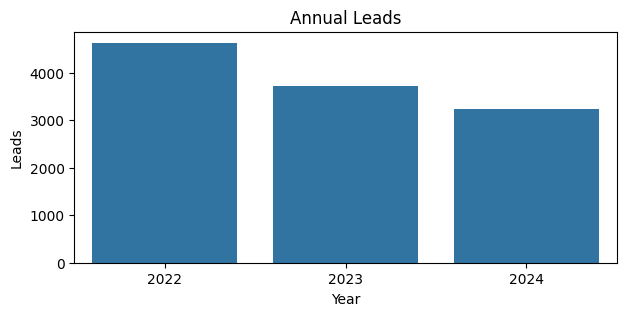

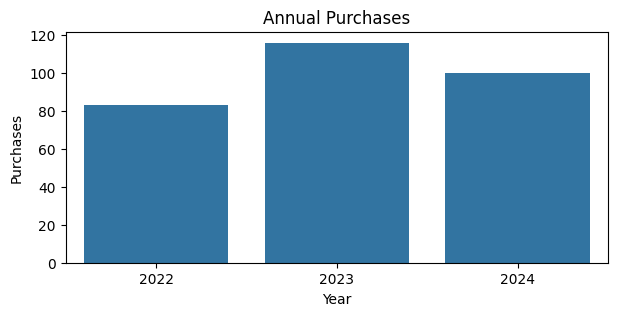

In [21]:
# ============================================================
# STEP 8. EXPLORATORY VISUALIZATIONS
# ============================================================

# ------------------------------------------------------------
# Evolution of leads and purchases by year
# ------------------------------------------------------------

annual_leads_purchases = grouped_df.groupby("year").agg({
    "leads count": "sum",
    "purchases count": "sum"
}).reset_index()
annual_leads_purchases

plt.figure(figsize=(7,3))

sns.barplot(data=annual_leads_purchases, x="year", y="leads count", errorbar=None, legend=False)

plt.title("Annual Leads")
plt.xlabel("Year")
plt.ylabel("Leads")
plt.show()

plt.figure(figsize=(7,3))

sns.barplot(data=annual_leads_purchases, x="year", y="purchases count", errorbar=None, legend=False)

plt.title("Annual Purchases")
plt.xlabel("Year")
plt.ylabel("Purchases")
plt.show()


In [22]:
df_2022_qualified_purchases = df_2022[["year", "month", "qualified leads count", "purchases count"]]
df_2023_qualified_purchases = df_2023[["year", "month", "qualified leads count", "purchases count"]]
df_2024_qualified_purchases = df_2024[["year", "month", "qualified leads count", "purchases count"]]

In [23]:
df_2022_qualified_purchases

,year,month,qualified leads count,purchases count
0,2022,2,24,0
1,2022,3,43,0
2,2022,4,45,4
3,2022,5,42,4
4,2022,6,45,10
5,2022,7,36,9
6,2022,8,42,10
7,2022,9,42,9
8,2022,10,41,12
9,2022,11,36,11


In [24]:
df_2023_qualified_purchases

,year,month,qualified leads count,purchases count
11,2023,1,31,11
12,2023,2,32,12
13,2023,3,42,10
14,2023,4,37,7
15,2023,5,33,7
16,2023,6,39,10
17,2023,7,26,9
18,2023,8,49,9
19,2023,9,38,9
20,2023,10,53,12


In [25]:
df_2024_qualified_purchases

,year,month,qualified leads count,purchases count
23,2024,1,60,8
24,2024,2,52,14
25,2024,3,56,8
26,2024,4,79,10
27,2024,5,70,17
28,2024,6,57,12
29,2024,7,53,16
30,2024,8,79,15


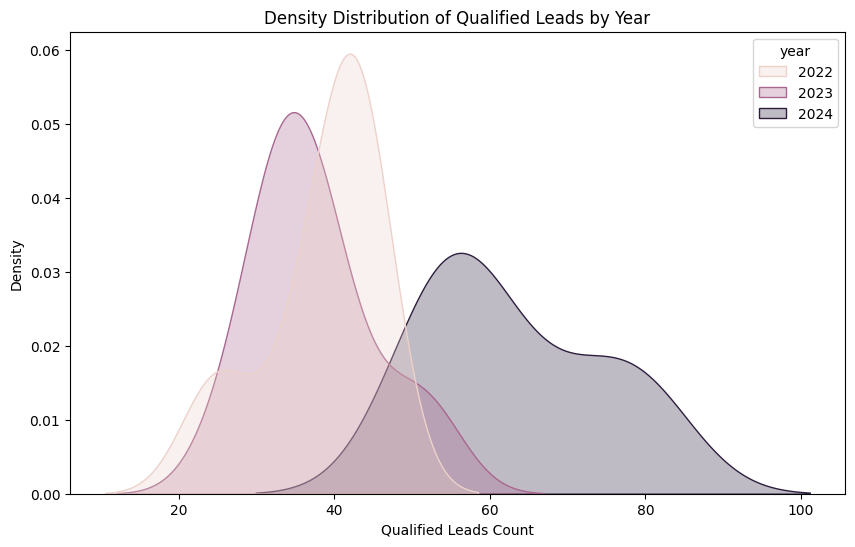

In [26]:
# Density distribution of qualified leads by year
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=grouped_df,
    x="qualified leads count",
    hue="year",
    fill=True,
    common_norm=False,
    alpha=0.3
)

plt.title("Density Distribution of Qualified Leads by Year")
plt.xlabel("Qualified Leads Count")

plt.show()

The density of qualified leads is also right‑skewed, with the highest density observed at low counts (0–20). The curves for 2022, 2023, and 2024 are very similar, implying consistent qualified lead generation across years. Notably, the 2024 distribution shows a slightly extended tail, suggesting occasional days with higher qualified lead volumes.

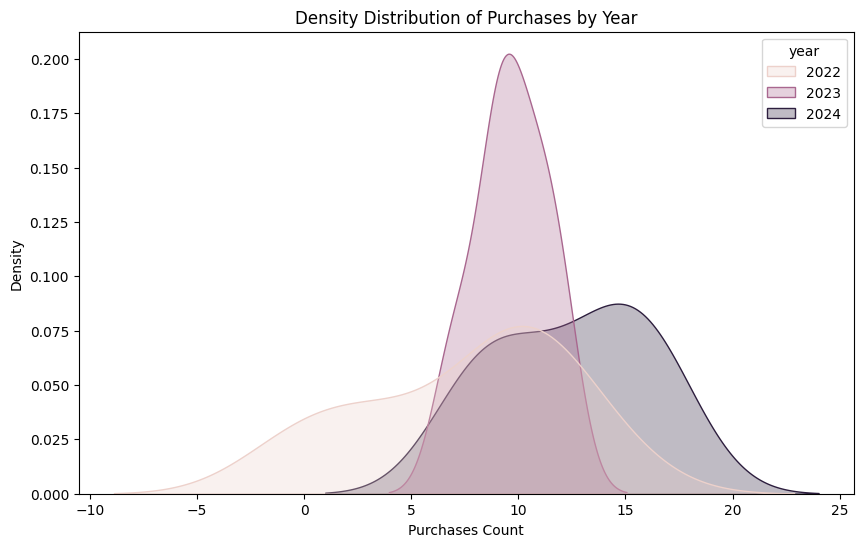

In [27]:
# Density distribution of purchases by year

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=grouped_df,
    x="purchases count",
    hue="year",
    fill=True,
    common_norm=False,
    alpha=0.3
)

plt.title("Density Distribution of Purchases by Year")
plt.xlabel("Purchases Count")

plt.show()

All three years display right‑skewed density curves, peaking near zero purchases. Most days result in few or no purchases, and the distributions for 2022, 2023, and 2024 largely overlap. This indicates stable purchase frequency over time with no clear upward or downward trend.

In [28]:
df_2022_qualified_purchases

,year,month,qualified leads count,purchases count
0,2022,2,24,0
1,2022,3,43,0
2,2022,4,45,4
3,2022,5,42,4
4,2022,6,45,10
5,2022,7,36,9
6,2022,8,42,10
7,2022,9,42,9
8,2022,10,41,12
9,2022,11,36,11


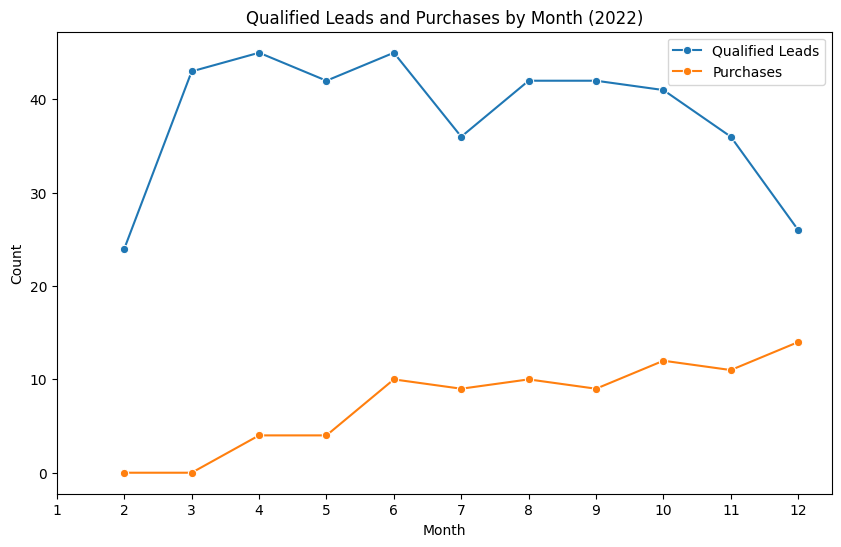

In [29]:
# Evolution of qualified leads and purchases by month in 2022
plt.figure(figsize=(10, 6))

# Qualified Leads
sns.lineplot(
    data=df_2022_qualified_purchases,
    x="month",
    y="qualified leads count",
    marker="o",
    label="Qualified Leads"
)

# Purchases
sns.lineplot(
    data=df_2022_qualified_purchases,
    x="month",
    y="purchases count",
    marker="o",
    label="Purchases"
)

plt.title("Qualified Leads and Purchases by Month (2022)")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(range(1, 13))
plt.legend()

plt.show()

In 2022, qualified leads started at 24 in February, peaked at 45 in April and June, then gradually declined to 26 by December. Purchases remained zero for the first three months but began increasing from April, reaching a maximum of 14 in December. The second half of the year showed a clear upward trend in purchases while qualified leads trended downward, indicating improved conversion efficiency later in the year.

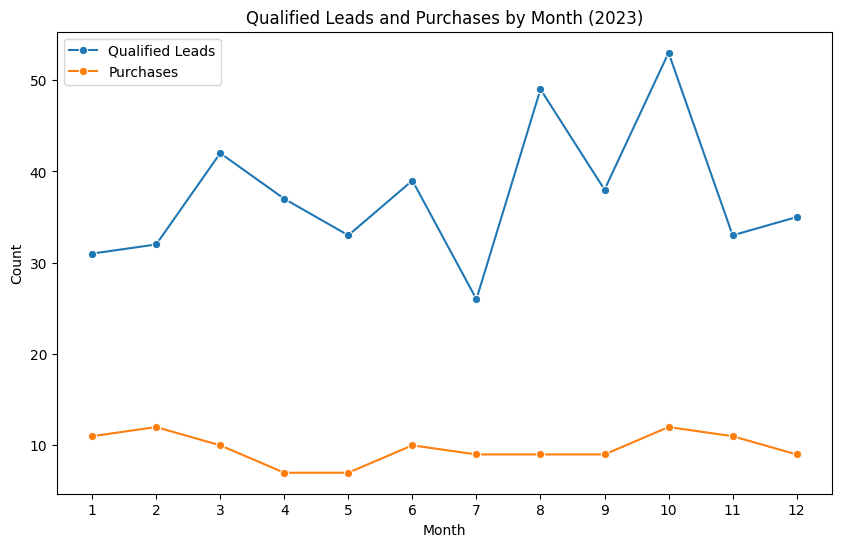

In [30]:
# Evolution of qualified leads and purchases by month in 2023
plt.figure(figsize=(10, 6))

# Qualified Leads
sns.lineplot(
    data=df_2023_qualified_purchases,
    x="month",
    y="qualified leads count",
    marker="o",
    label="Qualified Leads"
)

# Purchases
sns.lineplot(
    data=df_2023_qualified_purchases,
    x="month",
    y="purchases count",
    marker="o",
    label="Purchases"
)

plt.title("Qualified Leads and Purchases by Month (2023)")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(range(1, 13))
plt.legend()

plt.show()

In 2023, qualified leads were relatively stable throughout the year, ranging between 31 and 53, with peaks in March, June, August, and October. Purchases were consistently positive every month, varying between 7 and 12, with the highest values in February and October. Unlike 2022, there was no prolonged period of zero purchases, and the highest qualified lead count (53 in October) did not correspond to the highest purchases, suggesting that lead volume alone was not the main driver of final conversions.

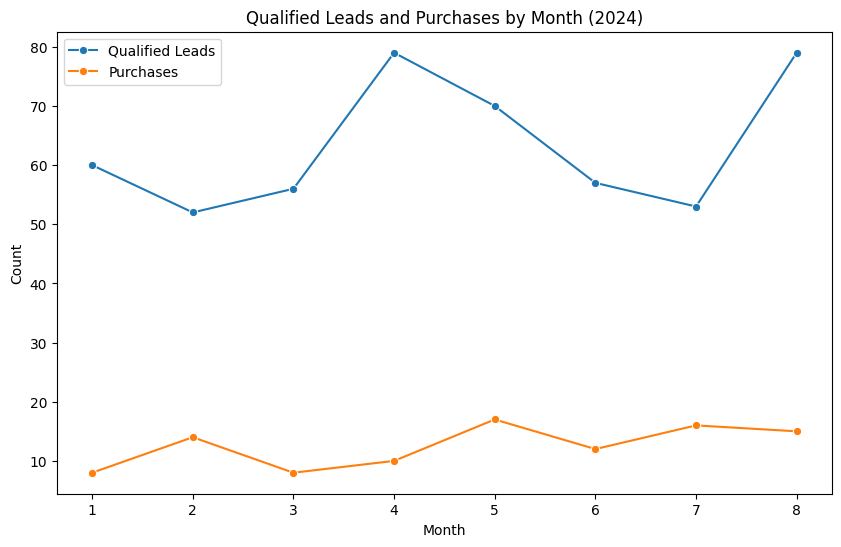

In [31]:
# Evolution of qualified leads and purchases by month in 2024
plt.figure(figsize=(10, 6))

# Qualified Leads
sns.lineplot(
    data=df_2024_qualified_purchases,
    x="month",
    y="qualified leads count",
    marker="o",
    label="Qualified Leads"
)

# Purchases
sns.lineplot(
    data=df_2024_qualified_purchases,
    x="month",
    y="purchases count",
    marker="o",
    label="Purchases"
)

plt.title("Qualified Leads and Purchases by Month (2024)")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(range(1, 9))
plt.legend()

plt.show()

In 2024, qualified leads were higher overall, ranging from 52 to 79, with peaks in April and August. Purchases also reached their highest levels, peaking at 17 in May, followed by 16 in July and 15 in August. Both metrics increased progressively from January to August without major drops, and the correlation between qualified leads and purchases appeared stronger than in previous years, indicating more efficient funnel progression. August recorded the highest qualified leads (79) and the second‑highest purchases (15), suggesting the channel mix in the latter part of the year was particularly effective.

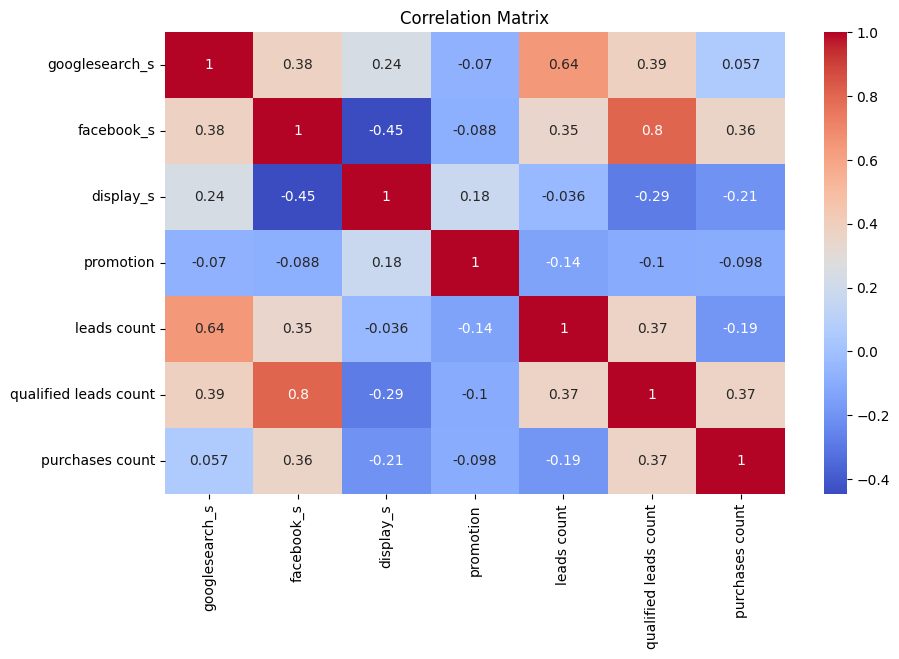

In [32]:
# ============================================================
# Correlation matrix
# ============================================================

corr_df = grouped_df[
    [
        "googlesearch_s",
        "facebook_s",
        "display_s",
        "promotion",
        "leads count",
        "qualified leads count",
        "purchases count"
    ]
]

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Facebook has the strongest positive correlation with qualified leads (0.8) and purchases (0.36). Google Search correlates most strongly with leads (0.64) but has near‑zero correlation with purchases (0.057). Display shows negative correlations with qualified leads (-0.29) and purchases (-0.21), suggesting it may not drive high‑quality conversions effectively. The promotion variable has weak negative correlations with all outcomes.

In [33]:
grouped_df.head()

,year,month,googlesearch_s,facebook_s,display_s,leads count,qualified leads count,purchases count,promotion
0,2022,2,68232.6400,10000.00,5709,442,24,0,0
1,2022,3,78032.9200,9957.69,7133,532,43,0,7
2,2022,4,99668.4050,9973.40,6821,452,45,4,0
3,2022,5,99610.7975,10068.91,6955,471,42,4,0
4,2022,6,99174.2265,9932.05,6784,369,45,10,7


In [34]:
# Machine Learning Models - Linear Regression

X_leads = grouped_df[["googlesearch_s", "facebook_s", "display_s", "promotion"]]
y_leads = grouped_df["leads count"]

X_qualified_leads = grouped_df[["googlesearch_s", "facebook_s", "display_s", "promotion"]]
y_qualified_leads = grouped_df["qualified leads count"]

X_purchases = grouped_df[["googlesearch_s", "facebook_s", "display_s", "promotion"]]
y_purchases = grouped_df["purchases count"]

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_leads, y_leads, test_size=0.25, random_state=42)
X_train_ql, X_test_ql, y_train_ql, y_test_ql = train_test_split(X_qualified_leads, y_qualified_leads, test_size=0.25, random_state=42)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_purchases, y_purchases, test_size=0.25, random_state=42)

In [35]:
# Model for leads
model_l = LinearRegression()
model_l.fit(X_train_l, y_train_l)
y_pred_l = model_l.predict(X_test_l)
r2_l = r2_score(y_test_l, y_pred_l)
mse_l = mean_squared_error(y_test_l, y_pred_l)
mae_l = mean_absolute_error(y_test_l, y_pred_l)

print("\n===== LEADS MODEL =====")
print("R²:", r2_l)
print("RMSE:", mse_l ** 0.5)
print("MAE:", mae_l)

print("\nCoefficients:")
print(
    pd.Series(
        model_l.coef_,
        index=X_train_l.columns
    )
)


===== LEADS MODEL =====
R²: 0.5800109207319271
RMSE: 38.600388685295016
MAE: 33.084506515512

Coefficients:
googlesearch_s    0.002762
facebook_s        0.002136
display_s        -0.024722
promotion        -2.193492
dtype: float64


In [36]:
# Model for qualified leads
model_ql = LinearRegression()
model_ql.fit(X_train_ql, y_train_ql)
y_pred_ql = model_ql.predict(X_test_ql)
r2_ql = r2_score(y_test_ql, y_pred_ql)
mse_ql = mean_squared_error(y_test_ql, y_pred_ql)
mae_ql = mean_absolute_error(y_test_ql, y_pred_ql)

print("\n===== QUALIFIED LEADS MODEL =====")
print("R²:", r2_ql)
print("RMSE:", mse_ql ** 0.5)
print("MAE:", mae_ql)

print("\nCoefficients:")
print(
    pd.Series(
        model_ql.coef_,
        index=X_train_ql.columns
    )
)


===== QUALIFIED LEADS MODEL =====
R²: 0.38708324263581695
RMSE: 10.89692823299193
MAE: 8.801972449364742

Coefficients:
googlesearch_s   -0.000056
facebook_s        0.002844
display_s         0.006456
promotion        -0.653624
dtype: float64


In [37]:
# Model for purchases
model_p = LinearRegression()
model_p.fit(X_train_p, y_train_p)
y_pred_p = model_p.predict(X_test_p)
r2_p = r2_score(y_test_p, y_pred_p)
mse_p = mean_squared_error(y_test_p, y_pred_p)
mae_p = mean_absolute_error(y_test_p, y_pred_p)

print("\n===== PURCHASES MODEL =====")
print("R²:", r2_p)
print("RMSE:", mse_p ** 0.5)
print("MAE:", mae_p)

print("\nCoefficients:")
print(
    pd.Series(
        model_p.coef_,
        index=X_train_p.columns
    )
)


===== PURCHASES MODEL =====
R²: -0.43863479990014276
RMSE: 4.14411666387518
MAE: 3.7277902260331786

Coefficients:
googlesearch_s   -0.000077
facebook_s        0.000304
display_s         0.001463
promotion        -0.014309
dtype: float64


In [38]:
# ============================================================
# STEP 14. COMPARE COEFFICIENTS
# ============================================================

# This table summarizes the estimated marginal impact
# of each channel on:
# - Leads
# - Qualified Leads
# - Purchases

results = pd.DataFrame({
    "Leads": model_l.coef_[:3],
    "Qualified": model_ql.coef_[:3],
    "Purchases": model_p.coef_[:3]
},
index=[
    "Google Search",
    "Facebook",
    "Display"
])

print("\n===== MARGINAL IMPACT PER CHANNEL =====")
print(results)

# ============================================================
# STEP 15. IDENTIFY THE BEST CHANNEL
# ============================================================

# For the final recommendation we prioritize:
#
# 1) Purchases
# 2) Qualified Leads
# 3) Leads
#
# The channel with the highest positive coefficient
# on Purchases will normally be the recommendation.

best_channel = results["Purchases"].idxmax()

print("\n===== PRELIMINARY RECOMMENDATION =====")
print(f"Recommended channel: {best_channel}")


===== MARGINAL IMPACT PER CHANNEL =====
                  Leads  Qualified  Purchases
Google Search  0.002762  -0.000056  -0.000077
Facebook       0.002136   0.002844   0.000304
Display       -0.024722   0.006456   0.001463

===== PRELIMINARY RECOMMENDATION =====
Recommended channel: Display


# 🎯 Final Conclusion

## 🏆 Recommended Channel: Display Advertising

The objective of this analysis was to determine which marketing channel should receive Amber Road's incremental advertising budget in order to maximize business impact.

After integrating daily marketing spend data with lead-level conversion data, performing exploratory analysis, and estimating the marginal effects of each channel through Linear Regression models, **Display Advertising emerged as the strongest investment opportunity**.

### 📊 Key Findings

* **Display generated the highest marginal impact on Purchases** *(β = 0.001463)*, the most important business outcome in the marketing funnel.
* **Display also showed the strongest positive effect on Qualified Leads** *(β = 0.006456)*.
* Facebook produced positive but smaller effects on both Qualified Leads and Purchases.
* Google Search generated additional leads, but its estimated impact on Qualified Leads and Purchases was slightly negative, suggesting that higher lead volume did not necessarily translate into stronger downstream conversion performance.

### 💡 Business Interpretation

The results suggest that **Display is not simply generating traffic—it is generating higher-quality prospects that are more likely to progress through the funnel and ultimately convert into customers**.

This distinction is critical. Marketing effectiveness should not be evaluated solely by the number of leads generated, but by the channel's ability to produce qualified prospects and purchases. Since purchases represent the final business objective, the channel with the strongest marginal effect on purchases should receive the incremental investment.

### 🚀 Recommendation

Based on the available evidence, **Amber Road should allocate its additional marketing budget to Display Advertising**.

Among the three channels analyzed, Display demonstrates the strongest expected return on incremental spending and the greatest contribution to the metrics that matter most for business growth.

**In short: if the goal is to maximize customer acquisition and downstream conversion performance, Display Advertising is the most data-supported choice.**

### ⚠️ Limitations

The analysis should be interpreted with caution. The dataset does not include channel-level lead attribution, revenue, or customer lifetime value (CLV). Therefore, the estimated effects should be viewed as statistical associations rather than definitive causal relationships.

Nevertheless, given the available data and modeling results, **Display Advertising provides the clearest and most defensible recommendation for incremental budget allocation.**